In [1]:
# position = torch.arange(0, 10)
# print(position.shape)
# div = 1 / (10000 ** (torch.arange(0, 100, 2)/100))
# print(div.shape)
# print(position * div)

In [2]:
# position = torch.arange(0, 10).unsqueeze(1)
# print(position.shape)
# div = 1 / (10000 ** (torch.arange(0, 100, 2)/100))
# print(div.shape)
# ans = position * div

In [3]:
import torch


In [4]:
import torchvision

In [5]:
import torch.optim as optim
from torchvision import datasets, transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

In [6]:
device = "cuda" if torch.cuda.is_available() else 'cpu'

In [7]:
device

'cuda'

In [8]:
T = 1000   ### num_timesteps
img_size = 28    ### images size is 28*28
Batch_Size = 28
epochs = 1
lr = 1e-3
base_channels = 64      ### used for U-Net

In [9]:
transform_1 = transforms.Compose([transforms.ToTensor(),
                                  transforms.Lambda(lambda x : 2*x - 1)])

#### generally the pixel value is between [0, 1] but unet work good with pixel range [-1, 1] so for that we used Lambda

In [10]:
train_dataset = datasets.FashionMNIST(train=True, root='data', transform=transform_1, download=True)
# test_dataset = datasets.FashionMNIST(train=False, root='data', transform=transform_1, download=True)
train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=Batch_Size, shuffle=True

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.1MB/s]


In [11]:
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1. - betas
alphas_bar = torch.cumprod(alphas, dim=0)

In [12]:
betas.shape

torch.Size([1000])

In [13]:
alphas[0] == alphas_bar[0]

tensor(True)

In [14]:
class PositionalEmbedding(nn.Module):
  def __init__(self, max_sequence_len, embedding_dim):
    super().__init__()
    self.max_sequence_len = max_sequence_len
    self.embedding_dim = embedding_dim
    pe = torch.zeros(self.max_sequence_len, self.embedding_dim)
    posi = torch.arange(0, self.embedding_dim, 2)
    num = torch.arange(0, self.max_sequence_len).unsqueeze(1)
    print(num.shape)
    denm = 1 / 10000 ** (posi /self.embedding_dim)
    print(denm.shape)
    pe[:, ::2] = torch.sin(num * denm)
    pe[:, 1::2] = torch.cos(num * denm)
    pe = pe.unsqueeze(0)
    self.register_buffer('pe', pe)

  def forward(self):
    return self.pe[:, :]


In [15]:
pos_emb = PositionalEmbedding(10, 100)
pos_emb().shape


torch.Size([10, 1])
torch.Size([50])


torch.Size([1, 10, 100])

In [16]:
### hey in this the each image channel is referred as each word in T
class TimeEmbedding(nn.Module):
  def __init__(self, num_timesteps, embedding_dim):
    super().__init__()
    self.num_timesteps = num_timesteps
    self.embedding_dim = embedding_dim
    pe = torch.zeros(self.num_timesteps, self.embedding_dim)
    posi = torch.arange(0, self.embedding_dim, 2)
    num = torch.arange(0, self.num_timesteps).unsqueeze(1)
    # print(num.shape)
    denm = 1 / 10000 ** (posi /self.embedding_dim)
    # print(denm.shape)
    pe[:, ::2] = torch.sin(num * denm)
    pe[:, 1::2] = torch.cos(num * denm)
    self.register_buffer('pe', pe)   ### pe become attribute and shape is (num_timesteps, embedding_dim)

  def forward(self, t):
    return self.pe[t]


In [17]:
time_emb = TimeEmbedding(10, 100)
time_emb(torch.tensor(5)).shape

torch.Size([100])

In [18]:
### Residual Block
class ResidualBlock(nn.Module):
  def __init__(self, in_channels, out_channels, tim_dim):
    super().__init__()
    self.norm1 = nn.GroupNorm(32, in_channels)
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    self.norm2 = nn.GroupNorm(32, out_channels)
    self.conv2 = nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            )

    self.time_proj = nn.Linear(tim_dim, out_channels)
    self.skip_layer = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

  def forward(self, x, t):
    h = self.conv1(F.relu(self.norm1(x)))
    h = h + self.time_proj(t)[:, : , None, None]
    h = self.conv2(F.relu(self.norm2(h)))
    return h + self.skip_layer(x)


In [19]:
class AttentionBlock(nn.Module):
  def __init__(self, channels):
    super().__init__()
    self.norm = nn.GroupNorm(32, channels)
    self.w_q = nn.Conv2d(channels, channels, kernel_size=1)
    self.w_k = nn.Conv2d(channels, channels, kernel_size=1)
    self.w_v = nn.Conv2d(channels, channels, kernel_size=1)
    self.proj = nn.Conv2d(channels, channels, kernel_size=1)

  def forward(self, x):
    B, C, H, W = x.shape
    h = self.norm(x)

    # Project and flatten spatial dimensions to (B, C, H*W)
    q = self.w_q(h).reshape(B, C, H * W)
    k = self.w_k(h).reshape(B, C, H * W)
    v = self.w_v(h).reshape(B, C, H * W)

    # Transpose q to (B, H*W, C) so that: (B, H*W, C) @ (B, C, H*W) -> (B, H*W, H*W)
    # This correctly computes energy/relationships between every pixel pair
    attn = q.transpose(1, 2) @ k
    attn = attn / torch.sqrt(torch.tensor(C, dtype=torch.float32, device=x.device))

    # Use functional softmax over the last dimension
    attn = torch.nn.functional.softmax(attn, dim=-1)

    # Compute weighted sum: (B, H*W, H*W) @ (B, H*W, C) -> (B, H*W, C)
    # Then transpose back to (B, C, H*W)
    h = (attn @ v.transpose(1, 2)).transpose(1, 2)

    # Reshape back to original spatial grid
    h = h.reshape(B, C, H, W)

    return self.proj(h) + x



In [20]:
import torch
import torch.nn as nn

x = torch.tensor([[[[1, 2],
                    [3, 4]]]], dtype=torch.float)  # shape (1,1,2,2)

upsample = nn.Upsample(scale_factor=2, mode='nearest')
y = upsample(x)

print(y)


tensor([[[[1., 1., 2., 2.],
          [1., 1., 2., 2.],
          [3., 3., 4., 4.],
          [3., 3., 4., 4.]]]])


In [21]:
from torch.nn.modules.pooling import AvgPool2d
class DDPMUNet(nn.Module):
  def __init__(self, num_timesteps, base_channels, in_channels = 1, out_channels = 1):
    super().__init__()
    time_dim = base_channels * 4        #### dimension of time_dimension

    self.conv1 = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)

    self.time_mlp = nn.Sequential(
        TimeEmbedding(num_timesteps , time_dim),
        nn.Linear(time_dim, time_dim),
        nn.GELU(),
        nn.Linear(time_dim, time_dim)
    )


    ## down
    self.down1 = ResidualBlock(base_channels, base_channels, time_dim)
    self.down2 = ResidualBlock(base_channels, 2*base_channels, time_dim)
    # self.down3 = ResidualBlock(2*base_channels, 2*base_channels, time_dim)
    self.pool = AvgPool2d(2)

    ## bottleneck
    self.mid1 = ResidualBlock(2*base_channels, 2*base_channels, time_dim)
    self.attention = AttentionBlock(2*base_channels)
    self.mid2 = ResidualBlock(2*base_channels, 2*base_channels, time_dim)

    ## up
    self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
    self.up1 = ResidualBlock(2*base_channels, base_channels, time_dim)
    self.up2 = ResidualBlock(2*base_channels, base_channels, time_dim)

    self.conv_out = nn.Conv2d(base_channels, out_channels, kernel_size=1, padding=0)

  def forward(self, x, t):
    t = self.time_mlp(t)

    x = self.conv1(x)
    d1 = self.down1(x, t)
    h = self.down2(d1, t)
    h = self.pool(h)

    h = self.mid1(h, t)
    h = self.attention(h)
    h = self.mid2(h, t)

    h = self.upsample(h)
    h = self.up1(h, t)
    h = torch.cat([h, d1], dim=1)
    h = self.up2(h, t)

    return self.conv_out(h)

In [22]:
model = DDPMUNet(T, base_channels).to(device)
optimizer = optim.AdamW(model.parameters(), lr=lr)

In [23]:
torch.randint(0, 10, (10, ))

tensor([4, 1, 2, 6, 9, 2, 3, 4, 1, 3])

In [24]:
def ForwardDiffusion(x, t):
  noise = torch.randn_like(x, device=device)
  sqrt_ab = torch.sqrt(alphas_bar[t])[:, None, None, None]
  sqrt_one_minus_ab = torch.sqrt(1 - alphas_bar[t])[:, None, None, None]
  xt = sqrt_ab * x + sqrt_one_minus_ab * noise
  return xt, noise

In [25]:
alphas_bar = alphas_bar.to(device) # Ensure alphas_bar is on the correct device

for epoch in range(epochs):
  step = 0
  for x, _ in train_loader:
    step +=1
    optimizer.zero_grad()
    x = x.to(device)
    t = torch.randint(0, T, (x.shape[0], ))  ### it create a tensor containing as many element as many pic as batch size
    xt, noise = ForwardDiffusion(x, t)
    noise_pred = model(xt, t)
    loss = F.mse_loss(noise_pred, noise)
    loss.backward()
    optimizer.step()

    if(step%100 == 0):
      print(f"epoch : {epoch} | loss : {loss.item():.4f}")

epoch : 0 | loss : 0.0705
epoch : 0 | loss : 0.0925
epoch : 0 | loss : 0.0964
epoch : 0 | loss : 0.0800
epoch : 0 | loss : 0.0903
epoch : 0 | loss : 0.0365
epoch : 0 | loss : 0.0373
epoch : 0 | loss : 0.0665
epoch : 0 | loss : 0.0792
epoch : 0 | loss : 0.0651
epoch : 0 | loss : 0.0490
epoch : 0 | loss : 0.0444
epoch : 0 | loss : 0.0669
epoch : 0 | loss : 0.0451
epoch : 0 | loss : 0.0893
epoch : 0 | loss : 0.0482
epoch : 0 | loss : 0.0440
epoch : 0 | loss : 0.0515
epoch : 0 | loss : 0.0775
epoch : 0 | loss : 0.0810
epoch : 0 | loss : 0.0458


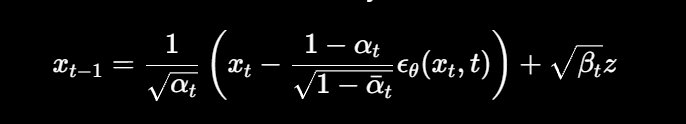

In [26]:
@torch.no_grad()
def sample(model, num_images, img_size, device):
    model.eval()

    # Start from pure Gaussian noise (x_T)
    x = torch.randn(num_images, 1, img_size, img_size).to(device)

    for t in reversed(range(T)):

        # Current timestep for every image in the batch
        t_batch = torch.full((num_images,), t,
                             device=device,
                             dtype=torch.long)    #### tensor of dim = 1 consiting of t-value for all images in batch

        # Predict the added noise
        pred_noise = model(x, t_batch)

        beta = betas[t].to(device)
        alpha = alphas[t].to(device)
        alpha_bar = alphas_bar[t].to(device)

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (
            1 / torch.sqrt(alpha)
        ) * (
            x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * pred_noise
        ) + torch.sqrt(beta) * noise

    return x

In [27]:
generated_images = sample(
    model,
    num_images=16,
    img_size=28,
    device=device
)

In [28]:
generated_images = (generated_images + 1) / 2
generated_images = generated_images.clamp(0, 1)

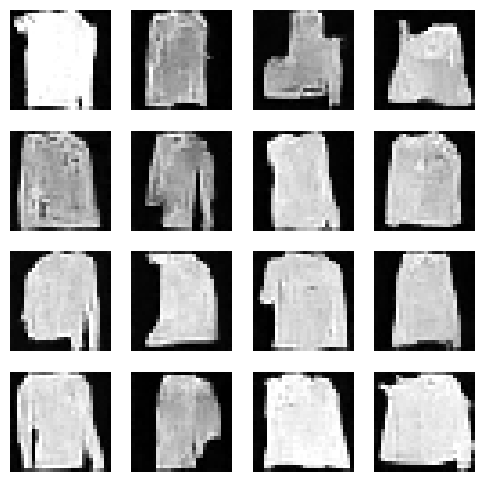

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(6,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i,0].cpu(), cmap="gray")
    ax.axis("off")

plt.show()